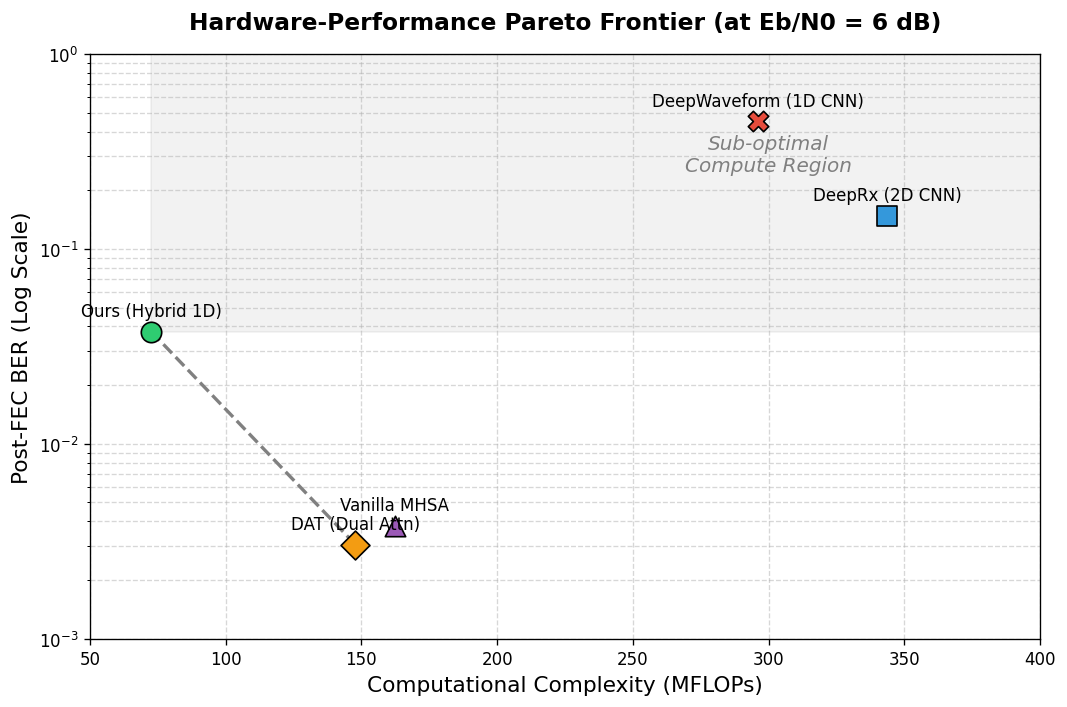

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. PARETO FRONTIER PLOT: COMPUTATIONAL COMPLEXITY VS. BER
# ==============================================================================

# Models
labels = ['Ours (Hybrid 1D)', 'DAT (Dual Attn)', 'Vanilla MHSA', 'DeepRx (2D CNN)', 'DeepWaveform (1D CNN)']

# X-Axis: FLOPs (in Millions) extracted from the logs
flops = [72.57, 147.81, 162.30, 343.72, 295.99]

# Y-Axis: Post-FEC BER at 6.0 dB (chosen because 8dB has zeros for Transformers which breaks log scale)
ber_6db = [3.765e-02, 3.037e-03, 3.790e-03, 1.477e-01, 4.534e-01]

colors = ['#2ecc71', '#f39c12', '#9b59b6', '#3498db', '#e74c3c']
markers = ['o', 'D', '^', 's', 'X']

plt.figure(figsize=(9, 6), dpi=120)

# Plot each model
for i in range(len(labels)):
    plt.scatter(flops[i], ber_6db[i], color=colors[i], marker=markers[i], s=150, label=labels[i], zorder=5, edgecolor='black')
    # Add text labels slightly offset
    plt.text(flops[i], ber_6db[i] * 1.2, labels[i], fontsize=10, ha='center', zorder=6)

# Draw the Pareto Frontier line (Connecting the dominating models: Ours -> DAT)
pareto_x = [flops[0], flops[1]]
pareto_y = [ber_6db[0], ber_6db[1]]
plt.plot(pareto_x, pareto_y, color='gray', linestyle='--', linewidth=2, zorder=3, label='Pareto Frontier')

# Shade the sub-optimal region
plt.fill_between([flops[0], 400], [ber_6db[0], ber_6db[0]], 1, color='gray', alpha=0.1, zorder=1)
plt.text(300, 0.25, "Sub-optimal\nCompute Region", color='gray', fontsize=12, ha='center', style='italic')

# Formatting
plt.yscale('log')
plt.title("Hardware-Performance Pareto Frontier (at Eb/N0 = 6 dB)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Computational Complexity (MFLOPs)", fontsize=13)
plt.ylabel("Post-FEC BER (Log Scale)", fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xlim(50, 400)
plt.ylim(1e-3, 1e0)
plt.tight_layout()

plt.show()